<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
college=pd.read_csv('./data/College.csv')
college.rename(columns={college.columns[0]: 'college'}, inplace=True)
college.head()

,college,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
#The shape
# The shape
print("Shape:")
print(college.shape)

# The data types of each column
print("\nData types of each column:")
print(college.dtypes)

# Number of missing values per column
print("\nNumber of missing values per column:")
print(college.isnull().sum())

Shape:
(777, 19)

Data types of each column:
college         object
Private         object
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD             object
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

Number of missing values per column:
college        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [4]:
# Your code here
college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')
college[college['PhD'] > 100]['PhD']

582    103.0
Name: PhD, dtype: float64

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [5]:
# Your code here 
college[college['Grad.Rate'] > 100].drop


<bound method DataFrame.drop of               college Private  Apps  Accept  Enroll  Top10perc  Top25perc  \
95  Cazenovia College     Yes  3847    3433     527          9         35   

    F.Undergrad  P.Undergrad  Outstate  Room.Board  Books  Personal   PhD  \
95         1010           12      9384        4840    600       500  22.0   

    Terminal  S.F.Ratio  perc.alumni  Expend  Grad.Rate  
95        47       14.3           20    7697        118  >

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [6]:
%%writefile myutils.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer


def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and
    recommends a transformation based on skewness.

    Returns a DataFrame with:
    Feature, Skewness, Degree, Direction,
    Recommended Transformation
    """

    results = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        skew_val = df[col].skew()
        abs_skew = abs(skew_val)

        # Determine Direction
        direction = "Positive" if skew_val >= 0 else "Negative"

        # Determine Degree of Skewness
        if abs_skew < 0.5:
            degree = "Approximately Symmetric"
        elif abs_skew <= 1.0:
            degree = "Moderately Skewed"
        else:
            degree = "Highly Skewed"

        # Recommend Transformation based on degree
        if abs_skew < 0.5:
            recommendation = "None needed"
        else:
            recommendation = "Box-Cox or Yeo-Johnson"

        results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })

    return pd.DataFrame(results)

Overwriting myutils.py


In [7]:
# Now import the function from myutils
from myutils import skew_calc


In [26]:
%%writefile myutils.py

def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

def plot_transformations(df, skew_table):

    for _, row in skew_table.iterrows():

        feature = row['Feature']
        recommendation = row['Recommended Transformation']

        original = df[feature].dropna()

        transformed = original.copy()

        try:

            if recommendation == 'Box-Cox or Yeo-Johnson':

                if original.min() > 0:
                    transformed, _ = boxcox(original)

                else:
                    pt = PowerTransformer(method='yeo-johnson')
                    transformed = pt.fit_transform(
                        original.values.reshape(-1,1)
                    ).flatten()

            elif recommendation == 'log(x+1) or Yeo-Johnson':

                transformed = np.log1p(original)

        except:
            transformed = original

        original_skew = original.skew()
        transformed_skew = pd.Series(transformed).skew()

        fig, axes = plt.subplots(1, 2, figsize=(10,4))

        axes[0].hist(original, bins=20)
        axes[0].set_title(
            f'Original {feature}\n(Skew: {original_skew:.2f})'
        )

        axes[1].hist(transformed, bins=20)
        axes[1].set_title(
            f'Best transformation: {recommendation.split()[0]} for {feature}\n'
            f'(Skew: {transformed_skew:.2f})'
        )

        plt.tight_layout()
        plt.show()

Overwriting myutils.py


#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [27]:
# Your code here
skew_table = skew_calc(college)
skew_table


,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


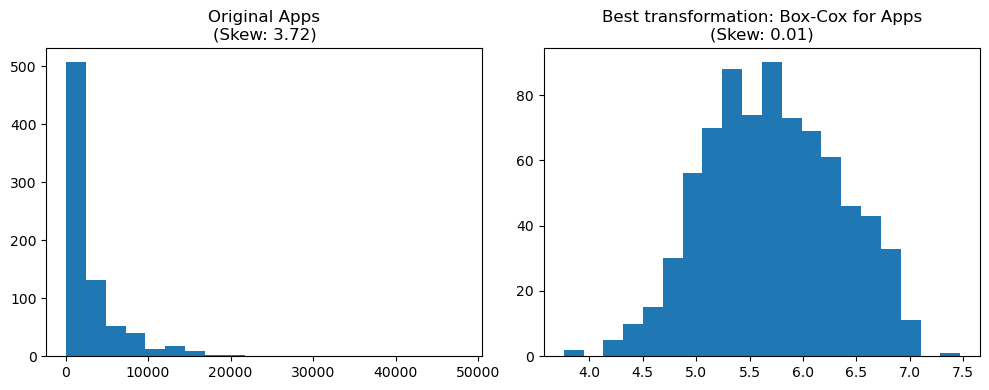

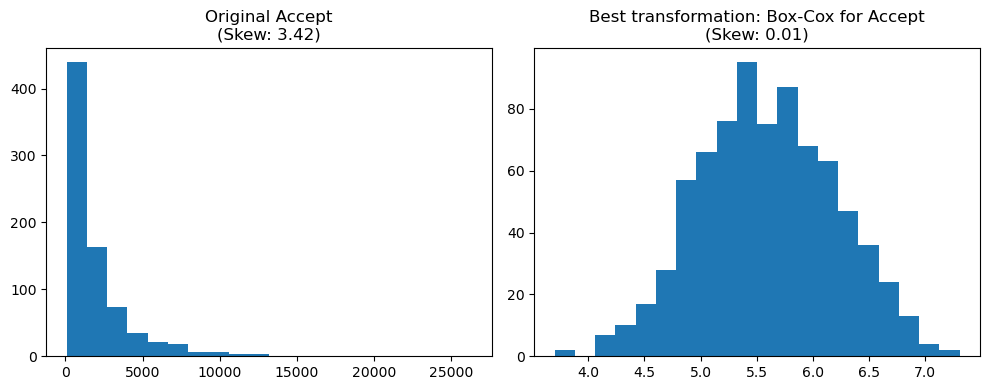

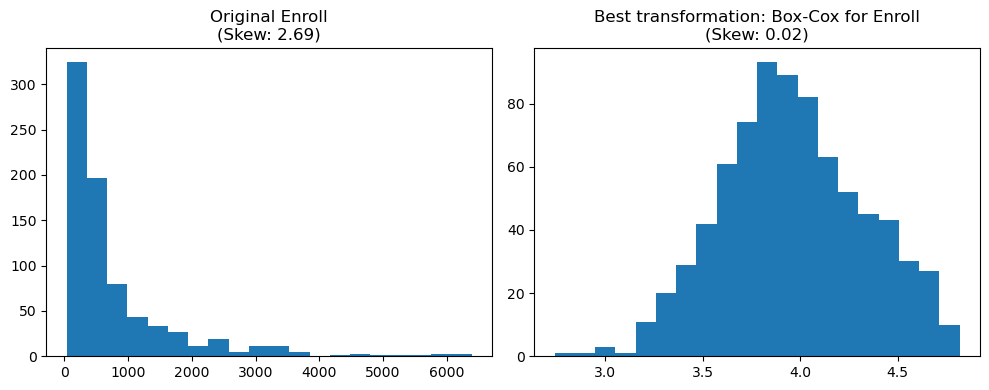

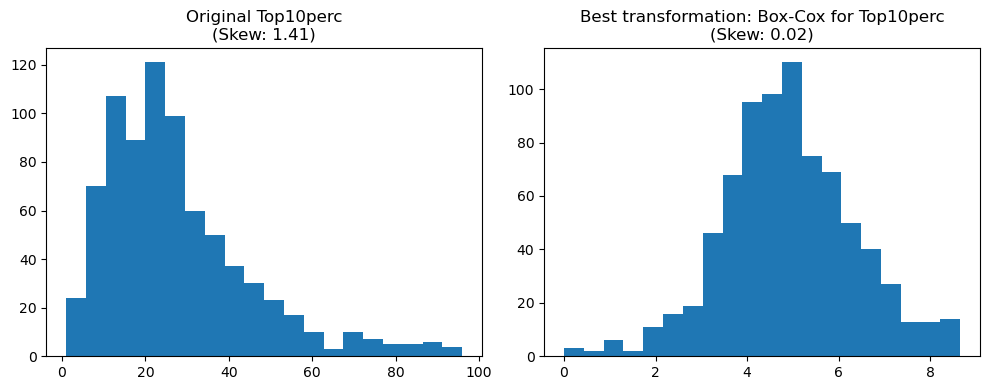

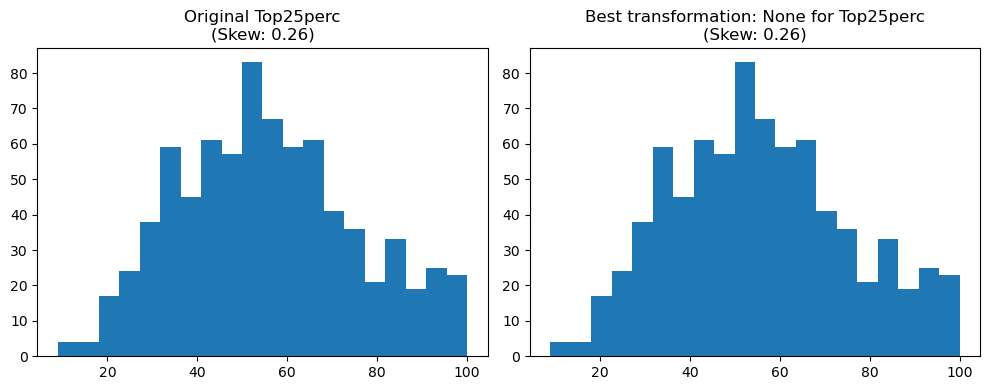

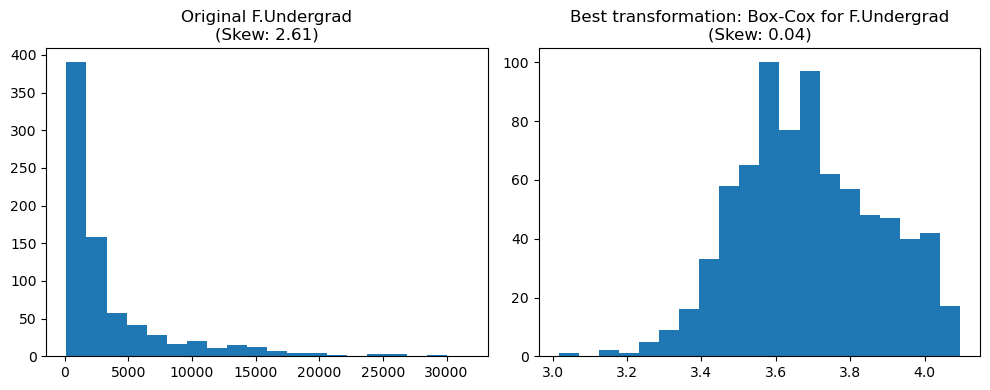

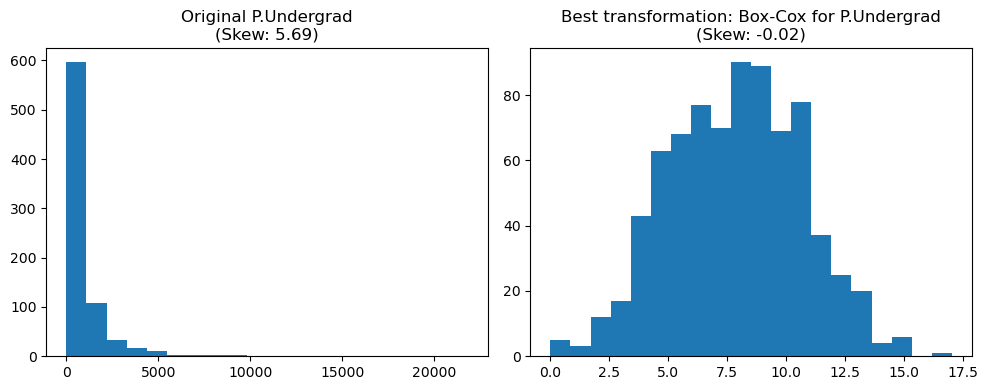

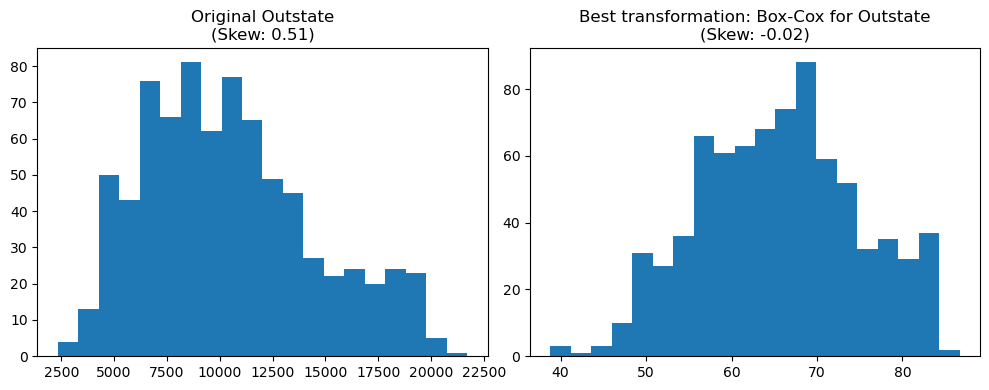

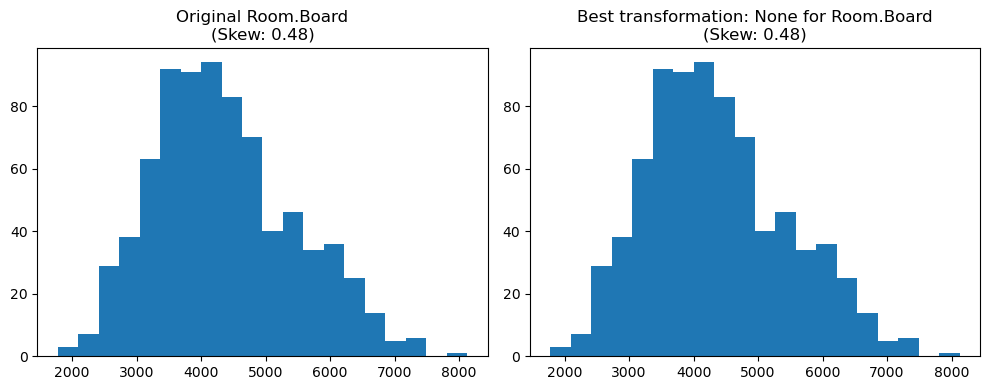

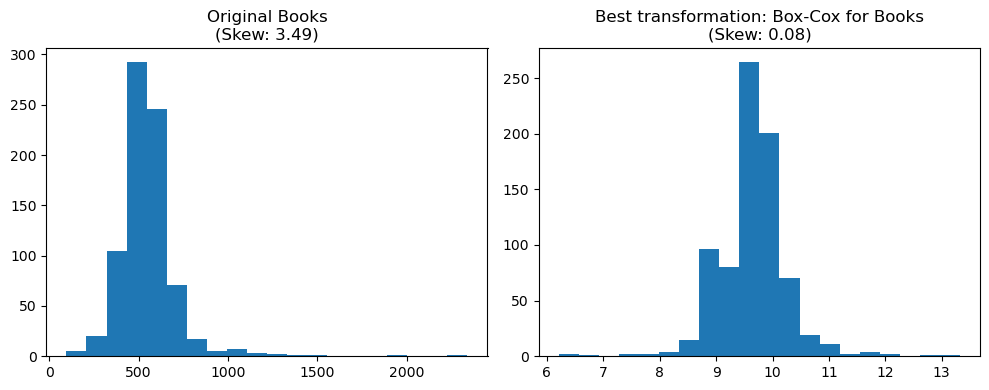

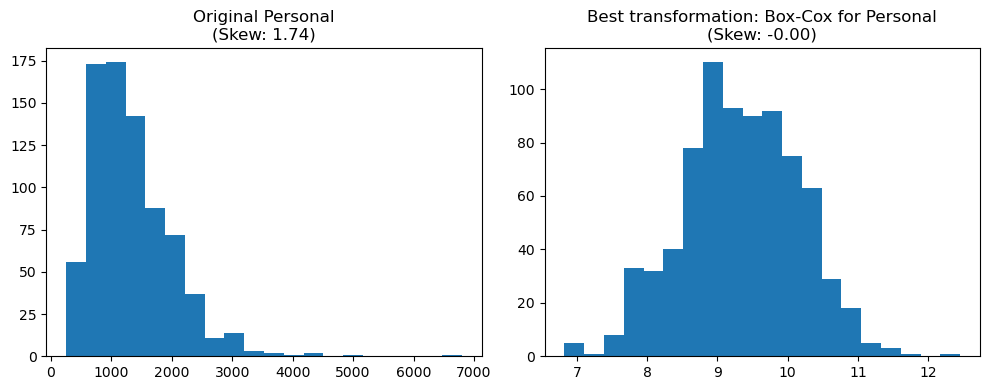

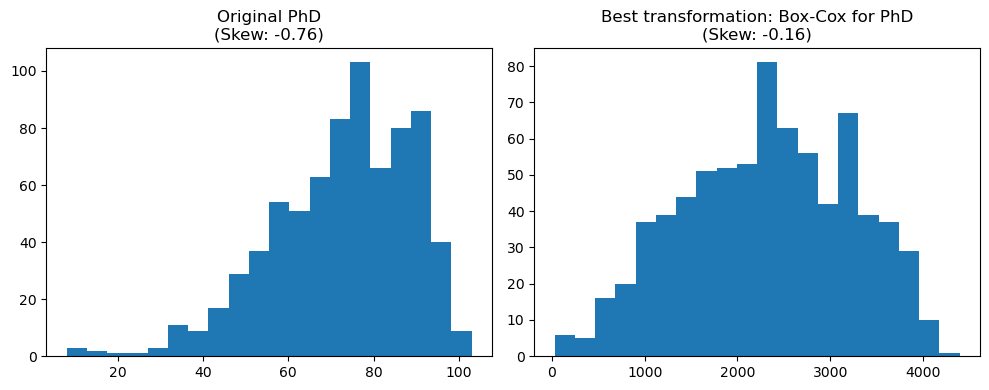

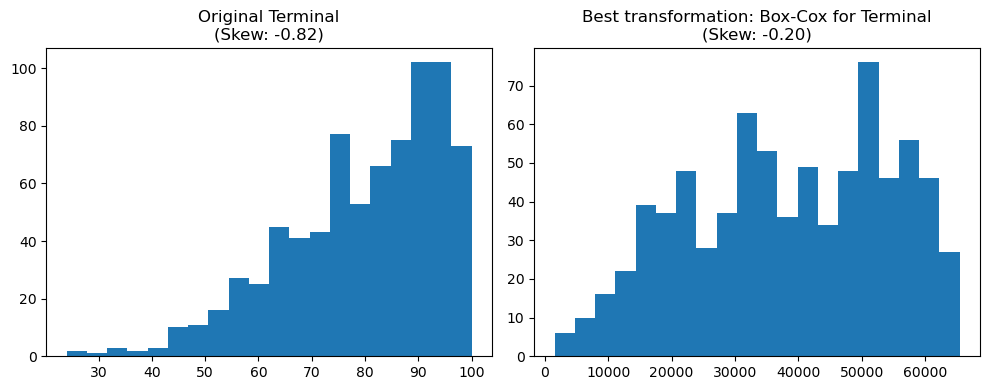

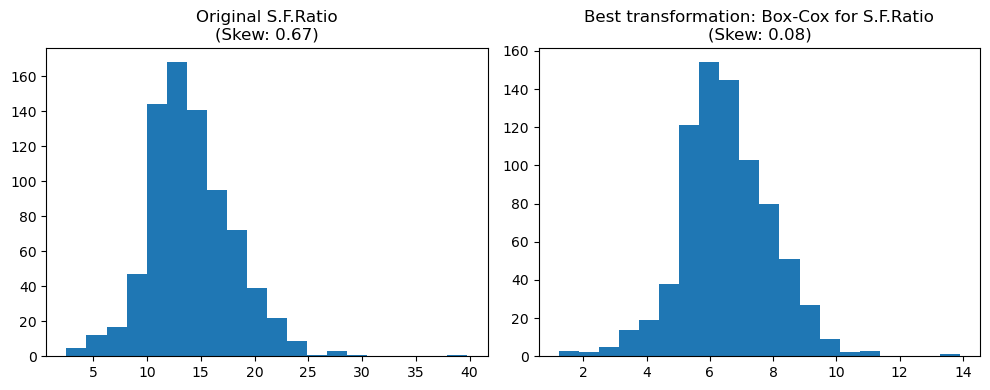

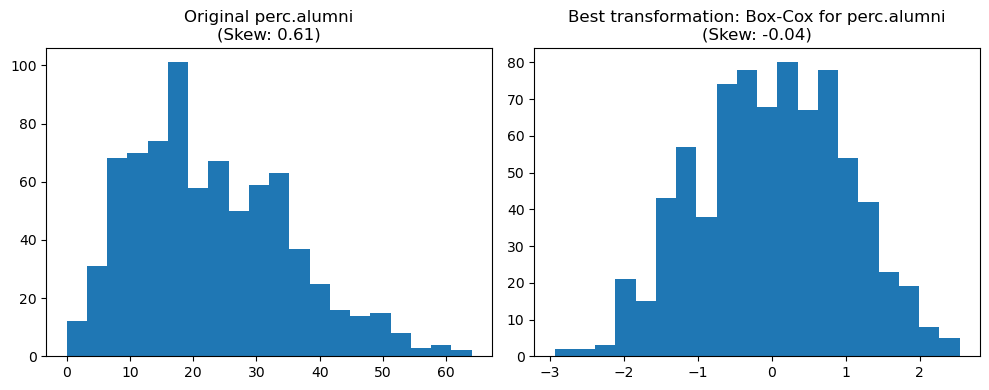

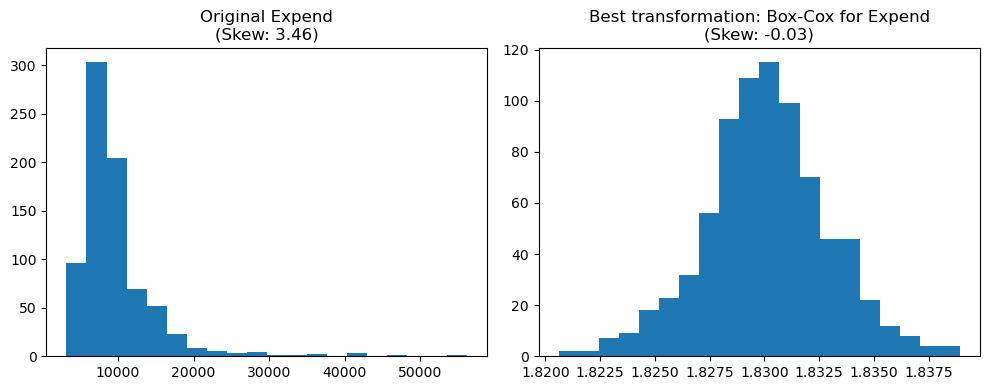

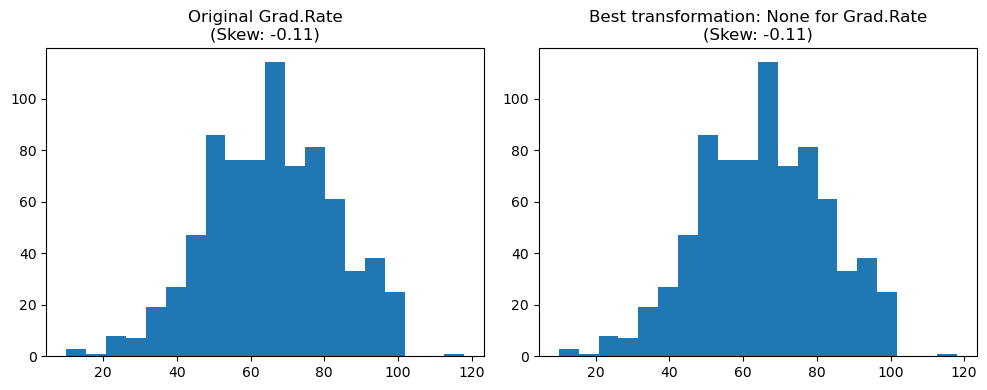

In [28]:
# Your code here
import importlib
import myutils
importlib.reload(myutils)  # myutils.py was appended to after the first import
from myutils import plot_transformations

plot_transformations(college, skew_table)

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [30]:
trans_cols = []

for _, row in skew_table.iterrows():

    col = row['Feature']
    method = row['Recommended Transformation']

    if method == 'None needed':
        continue

    new_col = f'{col}_trans'

    if method == 'log(x+1) or Yeo-Johnson':
        college[new_col] = np.log1p(college[col])

    elif method == 'Box-Cox or Yeo-Johnson':

        if college[col].min() > 0:
            pt = PowerTransformer(method='box-cox')
        else:
            pt = PowerTransformer(method='yeo-johnson')

        college[new_col] = pt.fit_transform(
            college[[col]]
        ).flatten()

    trans_cols.append(new_col)

print(trans_cols)
print(college[trans_cols].head())
# Your code here 

['Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']
   Apps_trans  Accept_trans  Enroll_trans  Top10perc_trans  F.Undergrad_trans  \
0    0.027794      0.041028      0.493375        -0.053119           0.433599   
1    0.282920      0.485821      0.142214        -0.584905           0.365382   
2   -0.113916     -0.077046     -0.315977        -0.120942          -0.636774   
3   -1.332769     -1.294446     -1.396388         1.614476          -1.531207   
4   -2.153050     -2.287608     -2.659212        -0.584905          -2.588901   

   P.Undergrad_trans  Outstate_trans  Books_trans  Personal_trans  PhD_trans  \
0           0.300156       -0.693449    -0.614254        1.271398  -0.279134   
1           0.868239        0.556268     1.302365        0.456551  -2.154737   
2          -0.727254       

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [31]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']
college[['college', 'Apps', 'Accept', 'Accept_Rate']].head()


,college,Apps,Accept,Accept_Rate
0,Abilene Christian University,1660,1232,0.742169
1,Adelphi University,2186,1924,0.880146
2,Adrian College,1428,1097,0.768207
3,Agnes Scott College,417,349,0.836930
4,Alaska Pacific University,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [32]:
# Your code here 
bins = [0, 7500, 10500, 14000, college['Outstate'].max() + 1]
labels = ['Low', 'Medium', 'High', 'Very High']

college['Outstate_Tier'] = pd.cut(college['Outstate'], bins=bins, labels=labels)
college[['Outstate', 'Outstate_Tier']].head()


,Outstate,Outstate_Tier
0,7440,Low
1,12280,High
2,11250,High
3,12960,High
4,7560,Medium


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [33]:
# Your code here 
tier_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
college['Outstate_Tier_encoded'] = college['Outstate_Tier'].map(tier_order)
college[['Outstate_Tier', 'Outstate_Tier_encoded']].head()


,Outstate_Tier,Outstate_Tier_encoded
0,Low,0
1,High,2
2,High,2
3,High,2
4,Medium,1


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [34]:
# Your code here 
college['Private_encoded'] = college['Private'].map({'Yes': 1, 'No': 0})
college[['Private', 'Private_encoded']].head()


,Private,Private_encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [35]:
cols_to_scale = []

# Your code here 
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_encoded', 'Private_encoded']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(college[cols_to_scale])

scaled_cols = [f'{c}_scaled' for c in cols_to_scale]
college[scaled_cols] = scaled_values

college[scaled_cols].head()


,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_scaled,Outstate_Tier_encoded_scaled,Private_encoded_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.279134,-0.282374,1.017946,-0.834712,-0.491183,-0.032372,-1.284556,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.154737,-2.248129,-0.435083,-0.432329,0.552362,0.906193,0.591572,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.236940,-1.040711,-0.250216,0.674492,0.096393,0.144750,0.591572,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.333077,1.364588,-1.741872,1.125798,1.726997,0.612225,0.591572,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.119060,-0.687052,-0.515571,-2.329357,0.637044,0.064955,-0.346492,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

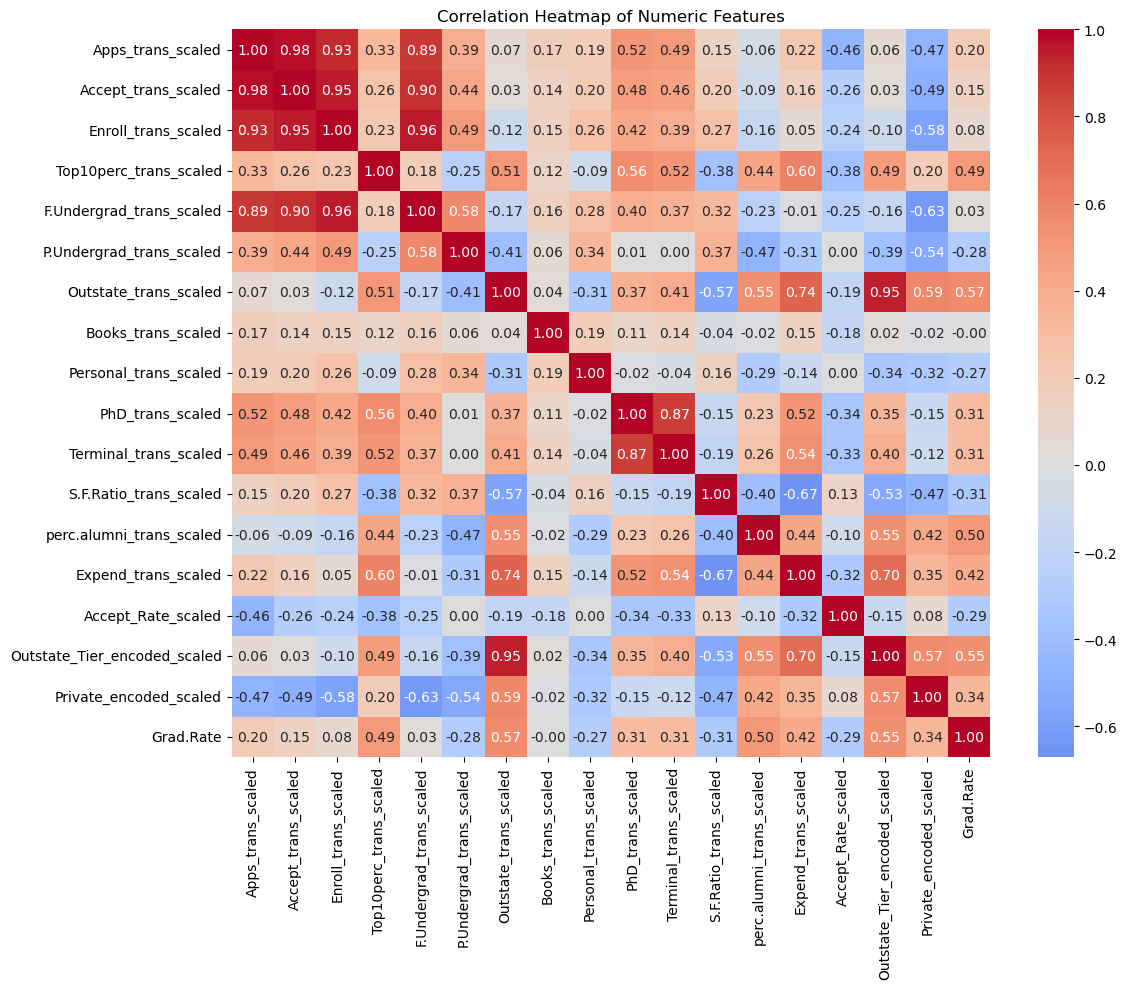

Highly correlated feature pairs (|corr| > 0.9):
  Apps_trans_scaled <-> Accept_trans_scaled: 0.977
  Apps_trans_scaled <-> Enroll_trans_scaled: 0.928
  Accept_trans_scaled <-> Enroll_trans_scaled: 0.948
  Accept_trans_scaled <-> F.Undergrad_trans_scaled: 0.905
  Enroll_trans_scaled <-> F.Undergrad_trans_scaled: 0.956
  Outstate_trans_scaled <-> Outstate_Tier_encoded_scaled: 0.947

Dropping redundant columns: ['Enroll_trans_scaled', 'Accept_trans_scaled', 'F.Undergrad_trans_scaled', 'Terminal_trans_scaled']


In [36]:
# Your code here 
nonskewed_cols = [
    c for c in skew_table.loc[skew_table['Recommended Transformation'] == 'None', 'Feature']
    if c != 'Grad.Rate'
]

corr_cols = scaled_cols + nonskewed_cols + ['Grad.Rate']
corr = college[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# `Grad.Rate` correlates most with perc.alumni, PhD_trans_scaled/Terminal_trans_scaled,
# and Outstate_Tier_encoded_scaled - schools with better-funded, more selective profiles
# tend to graduate more students.

# Check for highly correlated (redundant) feature pairs, excluding the target itself
corr_no_target = corr.drop(index='Grad.Rate', columns='Grad.Rate')
high_corr_pairs = []
for i, col_i in enumerate(corr_no_target.columns):
    for col_j in corr_no_target.columns[i + 1:]:
        value = corr_no_target.loc[col_i, col_j]
        if abs(value) > 0.9:
            high_corr_pairs.append((col_i, col_j, round(value, 3)))

print("Highly correlated feature pairs (|corr| > 0.9):")
for col_i, col_j, value in high_corr_pairs:
    print(f"  {col_i} <-> {col_j}: {value}")

# Drop one feature from each highly correlated pair (Apps/Accept/Enroll/F.Undergrad all
# move together, as do PhD/Terminal), keeping the more informative/representative column
cols_to_drop = {'Accept_trans_scaled', 'Enroll_trans_scaled', 'F.Undergrad_trans_scaled', 'Terminal_trans_scaled'}
cols_to_drop = [c for c in cols_to_drop if c in scaled_cols]
print(f"\nDropping redundant columns: {cols_to_drop}")
scaled_cols = [c for c in scaled_cols if c not in cols_to_drop]

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [40]:
# Your code here 
import numpy as np
from sklearn.model_selection import train_test_split

target = 'Grad.Rate'

skewed_features = [
    c for c in skew_table.loc[skew_table['Recommended Transformation'] != 'None', 'Feature'] 
    if c != target
]

nonskewed_features = [
    c for c in skew_table.loc[skew_table['Recommended Transformation'] == 'None', 'Feature']
    if c != target
]

engineered_features = ['Accept_Rate', 'Outstate_Tier_encoded', 'Private_encoded']

# --- خطوة مهمة: تطبيق التحويل وإنشاء الأعمدة في college إذا لم تكن موجودة ---
for col in skewed_features:
    if f'{col}_trans' not in college.columns:
        # يمكنك تغيير np.log1p بالتحويل الموصى به في skew_table
        college[f'{col}_trans'] = np.log1p(college[col])

# تجميع الميزات
untrans_predictors = skewed_features + nonskewed_features + engineered_features
trans_predictors = [f'{c}_trans' for c in skewed_features] + nonskewed_features + engineered_features

X_untrans = college[untrans_predictors]
X_trans = college[trans_predictors]
y = college[target]

# Split once on the index so both models see exactly the same rows in train/test
train_idx, test_idx = train_test_split(college.index, test_size=0.2, random_state=42)

X_untrans_train, X_untrans_test = X_untrans.loc[train_idx], X_untrans.loc[test_idx]
X_trans_train, X_trans_test = X_trans.loc[train_idx], X_trans.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")

Train size: 621, Test size: 156


#### 15. Fit a linear regression using the raw predictors


In [47]:

imputer = SimpleImputer(strategy='median')

X_untrans_train_imp = imputer.fit_transform(X_untrans_train)
X_untrans_test_imp = imputer.transform(X_untrans_test)

lr_untrans = LinearRegression()
lr_untrans.fit(X_untrans_train_imp, y_train)

y_pred_untrans = lr_untrans.predict(X_untrans_test_imp)
r2_untrans = r2_score(y_test, y_pred_untrans)

print(f"R-squared (untransformed predictors): {r2_untrans:.4f}")

R-squared (untransformed predictors): 0.4631


#### 16. Fit the same model using the log-transformed predictors

In [49]:
trans_predictors = []

# Your code here 
trans_predictors = list(X_trans.columns)

imputer_trans = SimpleImputer(strategy='median')
X_trans_train_imp = imputer_trans.fit_transform(X_trans_train)
X_trans_test_imp = imputer_trans.transform(X_trans_test)

lr_trans = LinearRegression()
lr_trans.fit(X_trans_train_imp, y_train)

y_pred_trans = lr_trans.predict(X_trans_test_imp)
r2_trans = r2_score(y_test, y_pred_trans)

print(f"R-squared (transformed predictors): {r2_trans:.4f}")


R-squared (transformed predictors): 0.4997


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [50]:
# Your code here 
if r2_trans > r2_untrans:
    print("\nThe transformed predictors improved the model's fit on the test set, "
          "since resolving the skew makes the linear relationship between "
          "predictors and Grad.Rate more stable and easier for the model to capture.")
else:
    print("\nThe transformation did not meaningfully improve (or slightly hurt) the "
          "test R-squared here, which can happen when the relationships were already "
          "fairly linear or when the extra variance introduced by the transformation "
          "doesn't help this particular train/test split.")



The transformed predictors improved the model's fit on the test set, since resolving the skew makes the linear relationship between predictors and Grad.Rate more stable and easier for the model to capture.


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [51]:
# Your code here 
college.to_csv('college_transformed.csv', index=False)
print("Saved cleaned and transformed data to college_transformed.csv")


Saved cleaned and transformed data to college_transformed.csv
